**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**LOAD THE DATASET**

In [2]:
df = pd.read_csv("Admission_Predict.csv")
print(df.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


**DATA PRE-PROCESSING**

In [3]:
df = df.drop(['Serial No.'], axis=1)
df['Admitted'] = df['Chance of Admit '] >= 0.5
df['Admitted'] = df['Admitted'].astype(int)

**FEATURE SELECTION**

In [4]:
X = df[['GRE Score', 'TOEFL Score', 'CGPA']]
y = df['Admitted']

**TRAIN-TEST-SPLIT**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**TRAIN DECISION TREE MODEL**

In [6]:
model = DecisionTreeClassifier(max_depth=3)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**MODEL PREDICTION**

In [7]:
y_pred = model.predict(X_test)

**MODEL EVALUATION**

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.925
Confusion Matrix:
 [[ 4  6]
 [ 0 70]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.40      0.57        10
           1       0.92      1.00      0.96        70

    accuracy                           0.93        80
   macro avg       0.96      0.70      0.77        80
weighted avg       0.93      0.93      0.91        80



**VISUALIZATION OF DECISION TREE**

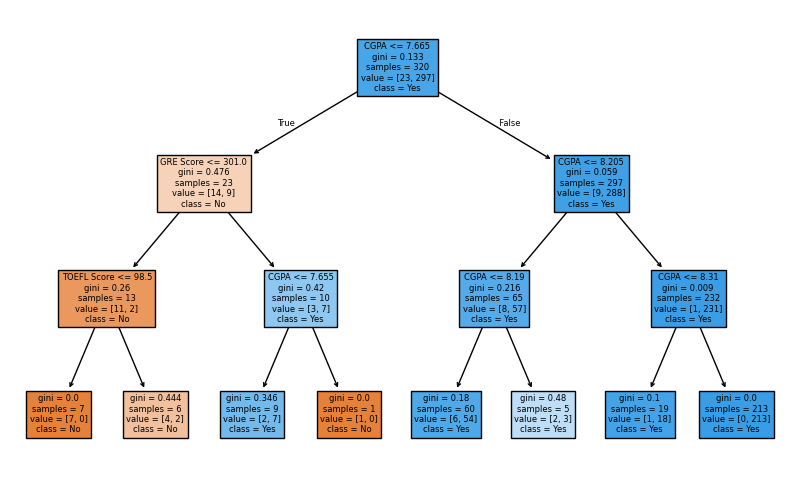

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()